# Objective 3 — Step 14: Final Explainability Analysis

The predictive framework is already frozen. **This notebook does not tune, select, or modify the model.**

## Frozen framework

**Leakage-controlled preprocessing → Group-aware Chi-Square Top-75% → Balanced LR + Balanced RF + Balanced XGBoost → Equal-probability Soft Voting → Sigmoid calibration → Training-derived MinCost FN:FP = 2:1 threshold**

## Explainability strategy

Two complementary analyses are used.

### 1. Primary explanation: source-feature permutation importance for the complete hybrid

Each original/source feature is permuted in the untouched outer-test fold while:

- all three fitted base learners remain fixed;
- the fitted sigmoid calibrator remains fixed;
- the training-derived decision threshold remains fixed.

Importance is measured as the deterioration in:

- ROC-AUC,
- PR-AUC,
- MCC,
- balanced accuracy,

and the increase in:

- Brier score,
- log loss.

Because permutation occurs at the **original variable level**, an entire categorical variable is perturbed together rather than perturbing individual one-hot dummy columns.

### 2. Component-level explanation: XGBoost SHAP contributions

For the XGBoost component only, native XGBoost SHAP contributions (`pred_contribs=True`) are calculated and aggregated from transformed columns back to their original source variables.

This is explicitly a **component-level** explanation; it is not presented as SHAP for the entire soft-voting hybrid.

## Validation principle

Explainability is computed on the already untouched outer-test partitions **after the framework has been frozen**. Outer-test labels are used only to quantify post-hoc permutation importance; they are never used to alter the model.

The notebook analyzes all three datasets and reuses the exact 25 outer folds from the earlier experiments.


In [1]:
%pip install pandas numpy scipy scikit-learn xgboost matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from IPython.display import display
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import chi2
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    log_loss,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

BASE_DIR = Path(r"D:\PHD\Research Paper writing\3rd Obj. paper")

RESULTS_DIR = BASE_DIR / "results"
DATA_DIR = BASE_DIR / "data" / "processed"

STEP2_DIR = RESULTS_DIR / "preprocessing_protocol"
STEP3_DIR = RESULTS_DIR / "baseline_models"
STEP9_DIR = RESULTS_DIR / "calibration_german_development"
STEP10_DIR = RESULTS_DIR / "frozen_sigmoid_calibration_replication"
STEP11_DIR = RESULTS_DIR / "threshold_german_development"
STEP12_DIR = RESULTS_DIR / "frozen_cost_aware_threshold_replication"

OUT_DIR = RESULTS_DIR / "final_explainability"
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DICTIONARY_FILE = STEP2_DIR / "preprocessing_data_dictionary.csv"
BASELINE_PREDICTIONS_FILE = STEP3_DIR / "baseline_predictions_all.csv"

GERMAN_CALIBRATORS_FILE = STEP9_DIR / "german_calibrator_parameters.csv"
EXTERNAL_CALIBRATORS_FILE = STEP10_DIR / "frozen_sigmoid_calibrator_parameters.csv"

GERMAN_THRESHOLD_FILE = STEP11_DIR / "german_thresholds_by_outer_run.csv"
EXTERNAL_THRESHOLD_FILE = STEP12_DIR / "frozen_cost_aware_thresholds_by_run.csv"

GERMAN_OUTER_PROB_FILE = STEP9_DIR / "german_calibration_outer_predictions.csv"
EXTERNAL_OUTER_PROB_FILE = STEP10_DIR / "frozen_sigmoid_replication_outer_predictions.csv"

DATASET_FILES = {
    "German Credit":
        DATA_DIR / "german_credit_cleaned.csv",
    "Australian Credit Approval":
        DATA_DIR / "australian_credit_approval_cleaned.csv",
    "Taiwan Credit Card Default":
        DATA_DIR / "taiwan_credit_card_default_cleaned.csv",
}

required = [
    DICTIONARY_FILE,
    BASELINE_PREDICTIONS_FILE,
    GERMAN_CALIBRATORS_FILE,
    EXTERNAL_CALIBRATORS_FILE,
    GERMAN_THRESHOLD_FILE,
    EXTERNAL_THRESHOLD_FILE,
    GERMAN_OUTER_PROB_FILE,
    EXTERNAL_OUTER_PROB_FILE,
    *DATASET_FILES.values(),
]

missing = [str(path) for path in required if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Required previous-step files are missing:\n"
        + "\n".join(missing)
    )

REPEAT_SEEDS = [42, 142, 242, 342, 442]
OUTER_FOLDS = 5
FROZEN_FRACTION = 0.75
BASE_MODELS = ["LR", "RF", "XGB"]

PERMUTATION_REPEATS = 5
SHAP_MAX_RECORDS_PER_OUTER_FOLD = 1000
EPS = 1e-6

DATASET_ORDER = [
    "German Credit",
    "Australian Credit Approval",
    "Taiwan Credit Card Default",
]

print("Output folder:", OUT_DIR)


Output folder: D:\PHD\Research Paper writing\3rd Obj. paper\results\final_explainability


## 1. Load data, feature roles, frozen calibrators, and frozen thresholds

In [3]:

dictionary = pd.read_csv(DICTIONARY_FILE)
baseline_predictions = pd.read_csv(BASELINE_PREDICTIONS_FILE)

german_calibrators = pd.read_csv(GERMAN_CALIBRATORS_FILE)
external_calibrators = pd.read_csv(EXTERNAL_CALIBRATORS_FILE)

german_thresholds = pd.read_csv(GERMAN_THRESHOLD_FILE)
external_thresholds = pd.read_csv(EXTERNAL_THRESHOLD_FILE)

german_outer_probabilities = pd.read_csv(GERMAN_OUTER_PROB_FILE)
external_outer_probabilities = pd.read_csv(EXTERNAL_OUTER_PROB_FILE)

datasets = {
    name: pd.read_csv(path)
    for name, path in DATASET_FILES.items()
}


def roles_for(dataset_name):
    d = dictionary[
        dictionary["dataset"] == dataset_name
    ].copy()

    return {
        role: (
            d.loc[
                d["role"] == role,
                "variable",
            ]
            .astype(str)
            .tolist()
        )
        for role in [
            "categorical",
            "ordinal",
            "numerical",
            "identifier",
        ]
    }


roles = {
    dataset_name: roles_for(dataset_name)
    for dataset_name in datasets
}


calibrators = pd.concat(
    [
        german_calibrators.assign(
            dataset="German Credit"
        ),
        external_calibrators,
    ],
    ignore_index=True,
    sort=False,
)


german_thresholds_selected = german_thresholds[
    german_thresholds["threshold_strategy"]
    == "MinCost_FN2_FP1"
].copy()

german_thresholds_selected["dataset"] = "German Credit"

external_thresholds_selected = external_thresholds.copy()

thresholds = pd.concat(
    [
        german_thresholds_selected[
            [
                "dataset",
                "run_id",
                "selected_threshold",
            ]
        ],
        external_thresholds_selected[
            [
                "dataset",
                "run_id",
                "selected_threshold",
            ]
        ],
    ],
    ignore_index=True,
)


outer_probabilities = pd.concat(
    [
        german_outer_probabilities.assign(
            dataset="German Credit"
        ),
        external_outer_probabilities,
    ],
    ignore_index=True,
    sort=False,
)


for dataset_name, df in datasets.items():
    r = roles[dataset_name]

    source_features = (
        r["categorical"]
        + r["ordinal"]
        + r["numerical"]
    )

    print(
        dataset_name,
        "| N =", len(df),
        "| source predictors =", len(source_features),
        "| Top75 =", math.ceil(
            len(source_features)
            * FROZEN_FRACTION
        ),
    )

assert len(calibrators) == 3 * 25
assert len(thresholds) == 3 * 25


German Credit | N = 1000 | source predictors = 20 | Top75 = 15
Australian Credit Approval | N = 690 | source predictors = 14 | Top75 = 11
Taiwan Credit Card Default | N = 30000 | source predictors = 23 | Top75 = 18


## 2. Fold-wise preprocessing

In [4]:

def make_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float32,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            dtype=np.float32,
        )


def build_preprocessor(
    dataset_name,
    mode,
    selected_features,
):
    r = roles[dataset_name]
    selected_features = list(selected_features)

    selected_cat = [
        feature
        for feature in r["categorical"]
        if feature in selected_features
    ]

    selected_ord = [
        feature
        for feature in r["ordinal"]
        if feature in selected_features
    ]

    selected_num = [
        feature
        for feature in r["numerical"]
        if feature in selected_features
    ]

    transformers = []

    if selected_num:
        if mode == "scaled":
            num_pipe = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ])
        elif mode == "tree":
            num_pipe = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
            ])
        elif mode == "chi2":
            num_pipe = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    MinMaxScaler(
                        clip=True
                    ),
                ),
            ])
        else:
            raise ValueError(mode)

        transformers.append(
            (
                "num",
                num_pipe,
                selected_num,
            )
        )

    if selected_ord:
        if mode == "scaled":
            ord_pipe = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ])
        elif mode == "tree":
            ord_pipe = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
            ])
        elif mode == "chi2":
            ord_pipe = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
                (
                    "scaler",
                    MinMaxScaler(
                        clip=True
                    ),
                ),
            ])
        else:
            raise ValueError(mode)

        transformers.append(
            (
                "ord",
                ord_pipe,
                selected_ord,
            )
        )

    if selected_cat:
        cat_pipe = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),
            (
                "onehot",
                make_one_hot_encoder(),
            ),
        ])

        transformers.append(
            (
                "cat",
                cat_pipe,
                selected_cat,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=True,
    )


## 3. Group-aware frozen Chi-Square Top-75%

In [5]:

def feature_map_from_fitted_preprocessor(
    fitted_preprocessor,
    dataset_name,
    selected_features,
):
    r = roles[dataset_name]
    selected_features = list(selected_features)

    selected_num = [
        feature
        for feature in r["numerical"]
        if feature in selected_features
    ]

    selected_ord = [
        feature
        for feature in r["ordinal"]
        if feature in selected_features
    ]

    selected_cat = [
        feature
        for feature in r["categorical"]
        if feature in selected_features
    ]

    rows = []
    index = 0

    for feature in selected_num:
        rows.append({
            "transformed_index": index,
            "source_feature": feature,
            "source_role": "numerical",
        })
        index += 1

    for feature in selected_ord:
        rows.append({
            "transformed_index": index,
            "source_feature": feature,
            "source_role": "ordinal",
        })
        index += 1

    if selected_cat:
        cat_pipeline = (
            fitted_preprocessor
            .named_transformers_[
                "cat"
            ]
        )

        encoder = (
            cat_pipeline
            .named_steps[
                "onehot"
            ]
        )

        for source_feature, categories in zip(
            selected_cat,
            encoder.categories_,
        ):
            for _ in categories:
                rows.append({
                    "transformed_index": index,
                    "source_feature": source_feature,
                    "source_role": "categorical",
                })
                index += 1

    feature_map = pd.DataFrame(
        rows
    )

    assert len(feature_map) == len(
        fitted_preprocessor
        .get_feature_names_out()
    )

    return feature_map


def group_aware_chi2_top75(
    dataset_name,
    X_train,
    y_train,
):
    r = roles[dataset_name]

    source_features = (
        r["categorical"]
        + r["ordinal"]
        + r["numerical"]
    )

    prep = build_preprocessor(
        dataset_name,
        "chi2",
        source_features,
    )

    X_chi = prep.fit_transform(
        X_train[
            source_features
        ],
        y_train,
    )

    assert np.asarray(
        X_chi
    ).min() >= -1e-12

    feature_map = (
        feature_map_from_fitted_preprocessor(
            prep,
            dataset_name,
            source_features,
        )
    )

    raw_scores, _ = chi2(
        X_chi,
        y_train,
    )

    temp = feature_map.copy()

    temp["raw_score"] = (
        pd.Series(
            raw_scores
        )
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
        .fillna(
            0.0
        )
        .to_numpy()
    )

    n = len(temp)

    transformed_rank = (
        temp[
            "raw_score"
        ].rank(
            ascending=False,
            method="average",
        )
    )

    if n > 1:
        temp[
            "normalized_relevance"
        ] = (
            1.0
            - (
                transformed_rank
                - 1.0
            )
            / (
                n
                - 1.0
            )
        )
    else:
        temp[
            "normalized_relevance"
        ] = 1.0

    grouped = (
        temp.groupby(
            "source_feature",
            as_index=False,
        )
        .agg(
            group_score=(
                "normalized_relevance",
                "mean",
            )
        )
    )

    grouped[
        "source_rank"
    ] = (
        grouped[
            "group_score"
        ].rank(
            ascending=False,
            method="average",
        )
    )

    grouped = (
        grouped.sort_values(
            [
                "source_rank",
                "source_feature",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    n_select = int(
        math.ceil(
            len(
                grouped
            )
            * FROZEN_FRACTION
        )
    )

    return (
        grouped[
            "source_feature"
        ]
        .astype(str)
        .tolist()[
            :n_select
        ]
    )


## 4. Frozen balanced heterogeneous hybrid

In [6]:

def balanced_ratio(
    y_train,
):
    n_positive = int(
        (
            y_train
            == 1
        ).sum()
    )

    n_negative = int(
        (
            y_train
            == 0
        ).sum()
    )

    return (
        n_negative
        / n_positive
    )


def build_balanced_base_pipeline(
    dataset_name,
    model_name,
    selected_features,
    y_train,
):
    if model_name == "LR":
        estimator = LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            class_weight="balanced",
            random_state=42,
        )

        mode = "scaled"

    elif model_name == "RF":
        estimator = RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )

        mode = "tree"

    elif model_name == "XGB":
        estimator = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=float(
                balanced_ratio(
                    y_train
                )
            ),
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        )

        mode = "tree"

    else:
        raise ValueError(
            model_name
        )

    return Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                dataset_name,
                mode,
                selected_features,
            ),
        ),
        (
            "model",
            estimator,
        ),
    ])


def fit_frozen_hybrid(
    dataset_name,
    X_train,
    y_train,
    selected_features,
):
    fitted = {}

    for model_name in BASE_MODELS:
        pipe = (
            build_balanced_base_pipeline(
                dataset_name,
                model_name,
                selected_features,
                y_train,
            )
        )

        pipe.fit(
            X_train[
                selected_features
            ],
            y_train,
        )

        fitted[
            model_name
        ] = pipe

    return fitted


def raw_hybrid_probability(
    fitted_models,
    X_predict,
    selected_features,
):
    probabilities = []

    for model_name in BASE_MODELS:
        probabilities.append(
            fitted_models[
                model_name
            ]
            .predict_proba(
                X_predict[
                    selected_features
                ]
            )[
                :,
                1,
            ]
        )

    return (
        np.column_stack(
            probabilities
        )
        .mean(
            axis=1
        )
    )


## 5. Frozen sigmoid and final operating threshold

In [7]:

def clip_probability(
    probability,
):
    return np.clip(
        np.asarray(
            probability,
            dtype=float,
        ),
        EPS,
        1.0
        - EPS,
    )


def probability_logit(
    probability,
):
    probability = (
        clip_probability(
            probability
        )
    )

    return np.log(
        probability
        / (
            1.0
            - probability
        )
    )


def apply_saved_sigmoid(
    raw_probability,
    intercept,
    slope,
):
    linear = (
        float(
            intercept
        )
        + float(
            slope
        )
        * probability_logit(
            raw_probability
        )
    )

    return (
        1.0
        / (
            1.0
            + np.exp(
                -linear
            )
        )
    )


def get_calibrator_parameters(
    dataset_name,
    run_id,
):
    row = calibrators[
        (
            calibrators[
                "dataset"
            ]
            == dataset_name
        )
        & (
            calibrators[
                "run_id"
            ]
            == run_id
        )
    ]

    if len(row) != 1:
        raise RuntimeError(
            f"Missing calibrator for "
            f"{dataset_name} {run_id}"
        )

    return (
        float(
            row[
                "sigmoid_intercept"
            ].iloc[0]
        ),
        float(
            row[
                "sigmoid_slope"
            ].iloc[0]
        ),
    )


def get_final_threshold(
    dataset_name,
    run_id,
):
    row = thresholds[
        (
            thresholds[
                "dataset"
            ]
            == dataset_name
        )
        & (
            thresholds[
                "run_id"
            ]
            == run_id
        )
    ]

    if len(row) != 1:
        raise RuntimeError(
            f"Missing threshold for "
            f"{dataset_name} {run_id}"
        )

    return float(
        row[
            "selected_threshold"
        ].iloc[0]
    )


## 6. Exact outer folds and saved-probability verification

In [8]:

def verified_outer_splits(
    dataset_name,
    df,
):
    r = roles[
        dataset_name
    ]

    source_features = (
        r["categorical"]
        + r["ordinal"]
        + r["numerical"]
    )

    X_local = df[
        source_features
    ].copy()

    y_local = (
        df[
            "adverse_target"
        ]
        .astype(int)
        .copy()
    )

    groups_local = (
        df[
            "profile_group_id"
        ]
        .astype(str)
        .copy()
    )

    saved = baseline_predictions[
        (
            baseline_predictions[
                "dataset"
            ]
            == dataset_name
        )
        & (
            baseline_predictions[
                "model"
            ]
            == "XGB"
        )
    ].copy()

    split_dict = {}

    for repeat_number, seed in enumerate(
        REPEAT_SEEDS,
        start=1,
    ):
        splitter = StratifiedGroupKFold(
            n_splits=OUTER_FOLDS,
            shuffle=True,
            random_state=seed,
        )

        for fold_number, (
            train_index,
            test_index,
        ) in enumerate(
            splitter.split(
                X_local,
                y_local,
                groups_local,
            ),
            start=1,
        ):
            run_id = (
                f"R{repeat_number}_"
                f"F{fold_number}"
            )

            expected_test = set(
                np.asarray(
                    test_index,
                    dtype=int,
                ).tolist()
            )

            saved_test = set(
                saved.loc[
                    saved[
                        "run_id"
                    ]
                    == run_id,
                    "source_row_index",
                ]
                .astype(int)
                .tolist()
            )

            assert (
                expected_test
                == saved_test
            )

            assert len(
                set(
                    groups_local.iloc[
                        train_index
                    ]
                ).intersection(
                    set(
                        groups_local.iloc[
                            test_index
                        ]
                    )
                )
            ) == 0

            split_dict[
                run_id
            ] = {
                "repeat": (
                    repeat_number
                ),
                "fold": (
                    fold_number
                ),
                "seed": seed,
                "train_idx": (
                    np.asarray(
                        train_index,
                        dtype=int,
                    )
                ),
                "test_idx": (
                    np.asarray(
                        test_index,
                        dtype=int,
                    )
                ),
            }

    return split_dict


outer_splits = {
    dataset_name: (
        verified_outer_splits(
            dataset_name,
            df,
        )
    )
    for dataset_name, df
    in datasets.items()
}

print(
    "All 75 outer folds "
    "match Step 3."
)


All 75 outer folds match Step 3.


## 7. Explainability metrics

In [9]:

def explainability_metrics(
    y_true,
    probability,
    threshold,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    probability = (
        clip_probability(
            probability
        )
    )

    prediction = (
        probability
        >= float(
            threshold
        )
    ).astype(int)

    return {
        "roc_auc": (
            roc_auc_score(
                y_true,
                probability,
            )
        ),
        "pr_auc": (
            average_precision_score(
                y_true,
                probability,
            )
        ),
        "brier": (
            brier_score_loss(
                y_true,
                probability,
            )
        ),
        "log_loss": (
            log_loss(
                y_true,
                probability,
                labels=[
                    0,
                    1,
                ],
            )
        ),
        "mcc": (
            matthews_corrcoef(
                y_true,
                prediction,
            )
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                prediction,
            )
        ),
    }


## 8. Full-hybrid source-feature permutation importance

Unselected source features receive zero importance for that outer fold because the frozen model did not use them.

For selected features, five deterministic independent permutations are evaluated.


In [10]:

permutation_rows = []
selection_rows = []
verification_rows = []

for dataset_name in DATASET_ORDER:
    df = datasets[
        dataset_name
    ]

    r = roles[
        dataset_name
    ]

    source_features = (
        r["categorical"]
        + r["ordinal"]
        + r["numerical"]
    )

    X_local = df[
        source_features
    ].copy()

    y_local = (
        df[
            "adverse_target"
        ]
        .astype(int)
        .copy()
    )

    print(
        "\n"
        + "=" * 80
    )

    print(
        dataset_name
    )

    print(
        "=" * 80
    )

    for run_number, (
        run_id,
        info,
    ) in enumerate(
        outer_splits[
            dataset_name
        ].items(),
        start=1,
    ):
        train_idx = (
            info[
                "train_idx"
            ]
        )

        test_idx = (
            info[
                "test_idx"
            ]
        )

        X_train = (
            X_local.iloc[
                train_idx
            ].copy()
        )

        X_test = (
            X_local.iloc[
                test_idx
            ].copy()
        )

        y_train = (
            y_local.iloc[
                train_idx
            ].copy()
        )

        y_test = (
            y_local.iloc[
                test_idx
            ].copy()
        )

        selected_features = (
            group_aware_chi2_top75(
                dataset_name,
                X_train,
                y_train,
            )
        )

        fitted_models = (
            fit_frozen_hybrid(
                dataset_name,
                X_train,
                y_train,
                selected_features,
            )
        )

        raw_probability = (
            raw_hybrid_probability(
                fitted_models,
                X_test,
                selected_features,
            )
        )

        intercept, slope = (
            get_calibrator_parameters(
                dataset_name,
                run_id,
            )
        )

        calibrated_probability = (
            apply_saved_sigmoid(
                raw_probability,
                intercept,
                slope,
            )
        )

        threshold = (
            get_final_threshold(
                dataset_name,
                run_id,
            )
        )

        original_metrics = (
            explainability_metrics(
                y_test,
                calibrated_probability,
                threshold,
            )
        )

        # Exact verification against saved calibrated probabilities.
        saved_run = (
            outer_probabilities[
                (
                    outer_probabilities[
                        "dataset"
                    ]
                    == dataset_name
                )
                & (
                    outer_probabilities[
                        "run_id"
                    ]
                    == run_id
                )
            ]
            .sort_values(
                "source_row_index"
            )
        )

        if dataset_name == "German Credit":
            saved_column = (
                "sigmoid_probability"
            )
        else:
            saved_column = (
                "sigmoid_probability"
            )

        current_order = (
            np.argsort(
                test_idx
            )
        )

        maximum_difference = float(
            np.max(
                np.abs(
                    calibrated_probability[
                        current_order
                    ]
                    - saved_run[
                        saved_column
                    ].to_numpy(
                        dtype=float
                    )
                )
            )
        )

        assert (
            maximum_difference
            < 1e-10
        ), (
            f"Probability reproduction failed: "
            f"{dataset_name} {run_id}, "
            f"max diff={maximum_difference}"
        )

        verification_rows.append({
            "dataset": (
                dataset_name
            ),
            "run_id": run_id,
            "max_abs_probability_difference": (
                maximum_difference
            ),
        })

        selected_set = set(
            selected_features
        )

        for source_feature in (
            source_features
        ):
            was_selected = (
                source_feature
                in selected_set
            )

            selection_rows.append({
                "dataset": (
                    dataset_name
                ),
                "run_id": run_id,
                "source_feature": (
                    source_feature
                ),
                "selected": int(
                    was_selected
                ),
            })

            if not was_selected:
                permutation_rows.append({
                    "dataset": (
                        dataset_name
                    ),
                    "run_id": run_id,
                    "repeat": (
                        info[
                            "repeat"
                        ]
                    ),
                    "fold": (
                        info[
                            "fold"
                        ]
                    ),
                    "source_feature": (
                        source_feature
                    ),
                    "permutation_repeat": 0,
                    "selected_in_fold": 0,
                    "roc_auc_drop": 0.0,
                    "pr_auc_drop": 0.0,
                    "mcc_drop": 0.0,
                    "balanced_accuracy_drop": 0.0,
                    "brier_increase": 0.0,
                    "log_loss_increase": 0.0,
                })

                continue

            feature_seed = (
                sum(
                    ord(
                        char
                    )
                    for char
                    in source_feature
                )
                + 1000
                * info[
                    "repeat"
                ]
                + 100
                * info[
                    "fold"
                ]
            )

            for permutation_repeat in range(
                1,
                PERMUTATION_REPEATS
                + 1,
            ):
                rng = (
                    np.random.default_rng(
                        feature_seed
                        + permutation_repeat
                    )
                )

                permuted_test = (
                    X_test.copy()
                )

                permuted_values = (
                    permuted_test[
                        source_feature
                    ].to_numpy(
                        copy=True
                    )
                )

                rng.shuffle(
                    permuted_values
                )

                permuted_test[
                    source_feature
                ] = permuted_values

                permuted_raw = (
                    raw_hybrid_probability(
                        fitted_models,
                        permuted_test,
                        selected_features,
                    )
                )

                permuted_calibrated = (
                    apply_saved_sigmoid(
                        permuted_raw,
                        intercept,
                        slope,
                    )
                )

                permuted_metrics = (
                    explainability_metrics(
                        y_test,
                        permuted_calibrated,
                        threshold,
                    )
                )

                permutation_rows.append({
                    "dataset": (
                        dataset_name
                    ),
                    "run_id": run_id,
                    "repeat": (
                        info[
                            "repeat"
                        ]
                    ),
                    "fold": (
                        info[
                            "fold"
                        ]
                    ),
                    "source_feature": (
                        source_feature
                    ),
                    "permutation_repeat": (
                        permutation_repeat
                    ),
                    "selected_in_fold": 1,
                    "roc_auc_drop": (
                        original_metrics[
                            "roc_auc"
                        ]
                        - permuted_metrics[
                            "roc_auc"
                        ]
                    ),
                    "pr_auc_drop": (
                        original_metrics[
                            "pr_auc"
                        ]
                        - permuted_metrics[
                            "pr_auc"
                        ]
                    ),
                    "mcc_drop": (
                        original_metrics[
                            "mcc"
                        ]
                        - permuted_metrics[
                            "mcc"
                        ]
                    ),
                    "balanced_accuracy_drop": (
                        original_metrics[
                            "balanced_accuracy"
                        ]
                        - permuted_metrics[
                            "balanced_accuracy"
                        ]
                    ),
                    "brier_increase": (
                        permuted_metrics[
                            "brier"
                        ]
                        - original_metrics[
                            "brier"
                        ]
                    ),
                    "log_loss_increase": (
                        permuted_metrics[
                            "log_loss"
                        ]
                        - original_metrics[
                            "log_loss"
                        ]
                    ),
                })

        print(
            f"{run_id} "
            f"({run_number}/25) | "
            f"selected={len(selected_features)} | "
            f"verification={maximum_difference:.1e}"
        )


permutation_detail = pd.DataFrame(
    permutation_rows
)

selection_detail = pd.DataFrame(
    selection_rows
)

verification = pd.DataFrame(
    verification_rows
)

permutation_detail.to_csv(
    OUT_DIR
    / "full_hybrid_source_permutation_importance_detail.csv",
    index=False,
)

selection_detail.to_csv(
    OUT_DIR
    / "explainability_feature_selection_by_run.csv",
    index=False,
)

verification.to_csv(
    OUT_DIR
    / "explainability_probability_reproduction_check.csv",
    index=False,
)

print(
    "\nPermutation importance completed."
)



German Credit
R1_F1 (1/25) | selected=15 | verification=1.1e-16
R1_F2 (2/25) | selected=15 | verification=1.1e-16
R1_F3 (3/25) | selected=15 | verification=1.1e-16
R1_F4 (4/25) | selected=15 | verification=1.7e-16
R1_F5 (5/25) | selected=15 | verification=2.2e-16
R2_F1 (6/25) | selected=15 | verification=1.7e-16
R2_F2 (7/25) | selected=15 | verification=1.1e-16
R2_F3 (8/25) | selected=15 | verification=1.1e-16
R2_F4 (9/25) | selected=15 | verification=1.4e-16
R2_F5 (10/25) | selected=15 | verification=2.2e-16
R3_F1 (11/25) | selected=15 | verification=1.7e-16
R3_F2 (12/25) | selected=15 | verification=1.1e-16
R3_F3 (13/25) | selected=15 | verification=1.1e-16
R3_F4 (14/25) | selected=15 | verification=1.7e-16
R3_F5 (15/25) | selected=15 | verification=2.2e-16
R4_F1 (16/25) | selected=15 | verification=1.1e-16
R4_F2 (17/25) | selected=15 | verification=1.1e-16
R4_F3 (18/25) | selected=15 | verification=1.7e-16
R4_F4 (19/25) | selected=15 | verification=1.1e-16
R4_F5 (20/25) | selected=

## 9. Summarize full-hybrid permutation importance

In [11]:

# First average permutation repeats within each fold-feature.
per_fold_permutation = (
    permutation_detail
    .groupby(
        [
            "dataset",
            "run_id",
            "source_feature",
        ],
        as_index=False,
    )
    .agg(
        selected_in_fold=(
            "selected_in_fold",
            "max",
        ),
        roc_auc_drop=(
            "roc_auc_drop",
            "mean",
        ),
        pr_auc_drop=(
            "pr_auc_drop",
            "mean",
        ),
        mcc_drop=(
            "mcc_drop",
            "mean",
        ),
        balanced_accuracy_drop=(
            "balanced_accuracy_drop",
            "mean",
        ),
        brier_increase=(
            "brier_increase",
            "mean",
        ),
        log_loss_increase=(
            "log_loss_increase",
            "mean",
        ),
    )
)

permutation_summary = (
    per_fold_permutation
    .groupby(
        [
            "dataset",
            "source_feature",
        ],
        as_index=False,
    )
    .agg(
        Selection_Frequency=(
            "selected_in_fold",
            "mean",
        ),
        ROC_AUC_Drop_Mean=(
            "roc_auc_drop",
            "mean",
        ),
        ROC_AUC_Drop_SD=(
            "roc_auc_drop",
            "std",
        ),
        PR_AUC_Drop_Mean=(
            "pr_auc_drop",
            "mean",
        ),
        MCC_Drop_Mean=(
            "mcc_drop",
            "mean",
        ),
        Balanced_Accuracy_Drop_Mean=(
            "balanced_accuracy_drop",
            "mean",
        ),
        Brier_Increase_Mean=(
            "brier_increase",
            "mean",
        ),
        LogLoss_Increase_Mean=(
            "log_loss_increase",
            "mean",
        ),
    )
)

permutation_summary[
    "Permutation_Rank"
] = (
    permutation_summary.groupby(
        "dataset"
    )[
        "ROC_AUC_Drop_Mean"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)

permutation_summary = (
    permutation_summary.sort_values(
        [
            "dataset",
            "Permutation_Rank",
        ]
    )
)

permutation_summary.to_csv(
    OUT_DIR
    / "full_hybrid_source_permutation_importance_summary.csv",
    index=False,
)

for dataset_name in DATASET_ORDER:
    print(
        "\n",
        dataset_name,
    )

    display(
        permutation_summary[
            permutation_summary[
                "dataset"
            ]
            == dataset_name
        ].head(
            12
        )
    )



 German Credit


,dataset,source_feature,Selection_Frequency,ROC_AUC_Drop_Mean,ROC_AUC_Drop_SD,PR_AUC_Drop_Mean,MCC_Drop_Mean,Balanced_Accuracy_Drop_Mean,Brier_Increase_Mean,LogLoss_Increase_Mean,Permutation_Rank
32,German Credit,status,1.00,0.101025,0.017721,0.129586,0.171427,0.092508,0.030568,0.077836,1.0
17,German Credit,duration,1.00,0.032715,0.011949,0.056557,0.059907,0.031688,0.011585,0.027464,2.0
30,German Credit,purpose,1.00,0.022949,0.008868,0.033450,0.040066,0.021344,0.007522,0.020464,3.0
15,German Credit,amount,1.00,0.022796,0.008733,0.032588,0.046961,0.024220,0.007428,0.018582,4.0
16,German Credit,credit_history,1.00,0.017464,0.008339,0.027110,0.030276,0.016636,0.006052,0.015690,5.0
31,German Credit,savings,1.00,0.014912,0.008619,0.036295,0.030854,0.016337,0.006019,0.013011,6.0
18,German Credit,employment_duration,1.00,0.007997,0.005985,0.010675,0.013573,0.007747,0.002543,0.006824,7.0
25,German Credit,other_installment_plans,1.00,0.007334,0.005983,0.003147,0.008854,0.004923,0.001659,0.006729,8.0
24,German Credit,other_debtors,0.92,0.006344,0.005417,0.007688,0.010713,0.005035,0.002252,0.005726,9.0
14,German Credit,age,0.80,0.004210,0.005923,0.007064,0.004497,0.003146,0.001326,0.003931,10.0



 Australian Credit Approval


,dataset,source_feature,Selection_Frequency,ROC_AUC_Drop_Mean,ROC_AUC_Drop_SD,PR_AUC_Drop_Mean,MCC_Drop_Mean,Balanced_Accuracy_Drop_Mean,Brier_Increase_Mean,LogLoss_Increase_Mean,Permutation_Rank
12,Australian Credit Approval,a8,1.00,0.247166,0.027125,0.200681,0.409299,0.213298,0.158827,0.416551,1.0
5,Australian Credit Approval,a14,1.00,0.014050,0.004875,0.006532,0.029221,0.013135,0.009775,0.030135,2.0
1,Australian Credit Approval,a10,1.00,0.007625,0.004703,0.005229,0.034057,0.016942,0.006135,0.016004,3.0
7,Australian Credit Approval,a3,1.00,0.005932,0.005721,0.008493,0.008021,0.004127,0.004044,0.012315,4.0
9,Australian Credit Approval,a5,1.00,0.003201,0.007543,0.007988,0.007691,0.005334,0.002352,0.007484,5.0
8,Australian Credit Approval,a4,1.00,0.002244,0.003635,0.002466,0.010879,0.005386,0.002499,0.005918,6.0
13,Australian Credit Approval,a9,1.00,0.002117,0.003265,-0.001810,0.016848,0.008939,0.002169,0.003876,7.0
11,Australian Credit Approval,a7,1.00,0.001721,0.003514,0.003782,-0.000834,0.001000,0.001524,0.006040,8.0
3,Australian Credit Approval,a12,0.88,0.000485,0.001811,0.001050,-0.000914,-0.000488,0.000641,0.001903,9.0
4,Australian Credit Approval,a13,0.04,0.000070,0.000348,0.000040,0.000691,0.000363,0.000123,0.000380,10.0



 Taiwan Credit Card Default


,dataset,source_feature,Selection_Frequency,ROC_AUC_Drop_Mean,ROC_AUC_Drop_SD,PR_AUC_Drop_Mean,MCC_Drop_Mean,Balanced_Accuracy_Drop_Mean,Brier_Increase_Mean,LogLoss_Increase_Mean,Permutation_Rank
44,Taiwan Credit Card Default,pay_0,1.00,0.080536,0.004191,0.197574,0.183839,0.086495,0.029474,0.068931,1.0
42,Taiwan Credit Card Default,limit_bal,1.00,0.015485,0.002538,0.012754,0.008960,0.008665,0.002077,0.007024,2.0
35,Taiwan Credit Card Default,bill_amt1,0.76,0.013389,0.008167,0.013439,0.003936,0.006228,0.002045,0.007114,3.0
50,Taiwan Credit Card Default,pay_amt1,1.00,0.007179,0.002008,0.006090,0.002839,0.007801,0.001156,0.003779,4.0
52,Taiwan Credit Card Default,pay_amt3,1.00,0.006828,0.002034,0.006180,0.001916,0.006056,0.000974,0.003233,5.0
53,Taiwan Credit Card Default,pay_amt4,1.00,0.006101,0.001830,0.005541,0.003000,0.006894,0.000947,0.003037,6.0
51,Taiwan Credit Card Default,pay_amt2,1.00,0.005606,0.001517,0.004318,0.004104,0.007089,0.000939,0.002942,7.0
45,Taiwan Credit Card Default,pay_2,1.00,0.005492,0.001019,0.011523,0.011585,0.009114,0.001897,0.004928,8.0
46,Taiwan Credit Card Default,pay_3,1.00,0.004416,0.001333,0.007984,0.007360,0.005585,0.001370,0.003547,9.0
41,Taiwan Credit Card Default,education,1.00,0.003449,0.001013,0.004063,0.001908,0.001550,0.000630,0.002050,10.0


## 10. XGBoost component-level SHAP contributions

Native XGBoost SHAP contributions are computed for a maximum of 1,000 outer-test records per fold for efficiency. All records are used when a test fold contains fewer than 1,000 cases.

Absolute SHAP contributions of one-hot columns are summed back to their original source variable.


In [12]:

shap_rows = []

for dataset_name in DATASET_ORDER:
    df = datasets[
        dataset_name
    ]

    r = roles[
        dataset_name
    ]

    source_features = (
        r["categorical"]
        + r["ordinal"]
        + r["numerical"]
    )

    X_local = df[
        source_features
    ].copy()

    y_local = (
        df[
            "adverse_target"
        ]
        .astype(int)
        .copy()
    )

    print(
        "\nSHAP:",
        dataset_name,
    )

    for run_number, (
        run_id,
        info,
    ) in enumerate(
        outer_splits[
            dataset_name
        ].items(),
        start=1,
    ):
        train_idx = (
            info[
                "train_idx"
            ]
        )

        test_idx = (
            info[
                "test_idx"
            ]
        )

        X_train = (
            X_local.iloc[
                train_idx
            ].copy()
        )

        X_test = (
            X_local.iloc[
                test_idx
            ].copy()
        )

        y_train = (
            y_local.iloc[
                train_idx
            ].copy()
        )

        selected_features = (
            group_aware_chi2_top75(
                dataset_name,
                X_train,
                y_train,
            )
        )

        xgb_pipe = (
            build_balanced_base_pipeline(
                dataset_name,
                "XGB",
                selected_features,
                y_train,
            )
        )

        xgb_pipe.fit(
            X_train[
                selected_features
            ],
            y_train,
        )

        if len(
            X_test
        ) > (
            SHAP_MAX_RECORDS_PER_OUTER_FOLD
        ):
            sample_rng = (
                np.random.default_rng(
                    70000
                    + info[
                        "seed"
                    ]
                    + info[
                        "fold"
                    ]
                )
            )

            sample_positions = (
                np.sort(
                    sample_rng.choice(
                        len(
                            X_test
                        ),
                        size=(
                            SHAP_MAX_RECORDS_PER_OUTER_FOLD
                        ),
                        replace=False,
                    )
                )
            )

            X_explain = (
                X_test.iloc[
                    sample_positions
                ].copy()
            )
        else:
            X_explain = (
                X_test.copy()
            )

        fitted_preprocessor = (
            xgb_pipe.named_steps[
                "preprocessor"
            ]
        )

        X_transformed = (
            fitted_preprocessor.transform(
                X_explain[
                    selected_features
                ]
            )
        )

        feature_map = (
            feature_map_from_fitted_preprocessor(
                fitted_preprocessor,
                dataset_name,
                selected_features,
            )
        )

        fitted_xgb = (
            xgb_pipe.named_steps[
                "model"
            ]
        )

        booster = (
            fitted_xgb.get_booster()
        )

        dmatrix = xgb.DMatrix(
            X_transformed
        )

        contributions = (
            booster.predict(
                dmatrix,
                pred_contribs=True,
                validate_features=False,
            )
        )

        # Last column is the bias/base-value contribution.
        feature_contributions = (
            contributions[
                :,
                :-1,
            ]
        )

        assert (
            feature_contributions.shape[
                1
            ]
            == len(
                feature_map
            )
        )

        transformed_importance = (
            feature_map.copy()
        )

        transformed_importance[
            "mean_abs_shap"
        ] = np.mean(
            np.abs(
                feature_contributions
            ),
            axis=0,
        )

        grouped = (
            transformed_importance
            .groupby(
                "source_feature",
                as_index=False,
            )
            .agg(
                mean_abs_shap=(
                    "mean_abs_shap",
                    "sum",
                )
            )
        )

        total_shap = float(
            grouped[
                "mean_abs_shap"
            ].sum()
        )

        grouped[
            "normalized_shap_share"
        ] = (
            grouped[
                "mean_abs_shap"
            ]
            / total_shap
            if total_shap > 0
            else 0.0
        )

        selected_set = set(
            selected_features
        )

        importance_lookup = {
            row[
                "source_feature"
            ]: (
                row[
                    "mean_abs_shap"
                ],
                row[
                    "normalized_shap_share"
                ],
            )
            for _, row
            in grouped.iterrows()
        }

        for source_feature in (
            source_features
        ):
            mean_abs_shap, shap_share = (
                importance_lookup.get(
                    source_feature,
                    (
                        0.0,
                        0.0,
                    ),
                )
            )

            shap_rows.append({
                "dataset": (
                    dataset_name
                ),
                "run_id": run_id,
                "repeat": (
                    info[
                        "repeat"
                    ]
                ),
                "fold": (
                    info[
                        "fold"
                    ]
                ),
                "source_feature": (
                    source_feature
                ),
                "selected_in_fold": int(
                    source_feature
                    in selected_set
                ),
                "records_explained": int(
                    len(
                        X_explain
                    )
                ),
                "mean_abs_shap": float(
                    mean_abs_shap
                ),
                "normalized_shap_share": float(
                    shap_share
                ),
            })

        print(
            f"{run_id} "
            f"({run_number}/25) | "
            f"records={len(X_explain)}"
        )


shap_detail = pd.DataFrame(
    shap_rows
)

shap_detail.to_csv(
    OUT_DIR
    / "xgb_source_shap_detail.csv",
    index=False,
)

shap_summary = (
    shap_detail
    .groupby(
        [
            "dataset",
            "source_feature",
        ],
        as_index=False,
    )
    .agg(
        Selection_Frequency=(
            "selected_in_fold",
            "mean",
        ),
        Mean_Absolute_SHAP=(
            "mean_abs_shap",
            "mean",
        ),
        SHAP_Share_Mean=(
            "normalized_shap_share",
            "mean",
        ),
        SHAP_Share_SD=(
            "normalized_shap_share",
            "std",
        ),
    )
)

shap_summary[
    "SHAP_Rank"
] = (
    shap_summary.groupby(
        "dataset"
    )[
        "SHAP_Share_Mean"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)

shap_summary = (
    shap_summary.sort_values(
        [
            "dataset",
            "SHAP_Rank",
        ]
    )
)

shap_summary.to_csv(
    OUT_DIR
    / "xgb_source_shap_summary.csv",
    index=False,
)

for dataset_name in DATASET_ORDER:
    print(
        "\n",
        dataset_name,
    )

    display(
        shap_summary[
            shap_summary[
                "dataset"
            ]
            == dataset_name
        ].head(
            12
        )
    )



SHAP: German Credit
R1_F1 (1/25) | records=200
R1_F2 (2/25) | records=200
R1_F3 (3/25) | records=200
R1_F4 (4/25) | records=200
R1_F5 (5/25) | records=200
R2_F1 (6/25) | records=200
R2_F2 (7/25) | records=200
R2_F3 (8/25) | records=200
R2_F4 (9/25) | records=200
R2_F5 (10/25) | records=200
R3_F1 (11/25) | records=200
R3_F2 (12/25) | records=200
R3_F3 (13/25) | records=200
R3_F4 (14/25) | records=200
R3_F5 (15/25) | records=200
R4_F1 (16/25) | records=200
R4_F2 (17/25) | records=200
R4_F3 (18/25) | records=200
R4_F4 (19/25) | records=200
R4_F5 (20/25) | records=200
R5_F1 (21/25) | records=200
R5_F2 (22/25) | records=200
R5_F3 (23/25) | records=200
R5_F4 (24/25) | records=200
R5_F5 (25/25) | records=200

SHAP: Australian Credit Approval
R1_F1 (1/25) | records=138
R1_F2 (2/25) | records=138
R1_F3 (3/25) | records=138
R1_F4 (4/25) | records=138
R1_F5 (5/25) | records=138
R2_F1 (6/25) | records=138
R2_F2 (7/25) | records=138
R2_F3 (8/25) | records=138
R2_F4 (9/25) | records=138
R2_F5 (10/2

,dataset,source_feature,Selection_Frequency,Mean_Absolute_SHAP,SHAP_Share_Mean,SHAP_Share_SD,SHAP_Rank
32,German Credit,status,1.0,0.980744,0.198766,0.015493,1.0
30,German Credit,purpose,1.0,0.588012,0.119095,0.010133,2.0
17,German Credit,duration,1.0,0.459758,0.093119,0.010430,3.0
15,German Credit,amount,1.0,0.455045,0.092249,0.012713,4.0
16,German Credit,credit_history,1.0,0.441641,0.089294,0.015156,5.0
31,German Credit,savings,1.0,0.362566,0.073567,0.011687,6.0
18,German Credit,employment_duration,1.0,0.349581,0.070728,0.010440,7.0
29,German Credit,property,1.0,0.233663,0.047237,0.010517,8.0
14,German Credit,age,0.8,0.204540,0.041526,0.021893,9.0
25,German Credit,other_installment_plans,1.0,0.199431,0.040484,0.007826,10.0



 Australian Credit Approval


,dataset,source_feature,Selection_Frequency,Mean_Absolute_SHAP,SHAP_Share_Mean,SHAP_Share_SD,SHAP_Rank
12,Australian Credit Approval,a8,1.00,2.138422,0.365737,0.013498,1.0
5,Australian Credit Approval,a14,1.00,0.623680,0.106593,0.017561,2.0
9,Australian Credit Approval,a5,1.00,0.561803,0.096079,0.017119,3.0
11,Australian Credit Approval,a7,1.00,0.518071,0.088480,0.012624,4.0
7,Australian Credit Approval,a3,1.00,0.517602,0.088362,0.011167,5.0
1,Australian Credit Approval,a10,1.00,0.472581,0.080846,0.011935,6.0
6,Australian Credit Approval,a2,1.00,0.379213,0.064744,0.007582,7.0
8,Australian Credit Approval,a4,1.00,0.280400,0.047866,0.011361,8.0
10,Australian Credit Approval,a6,1.00,0.246674,0.042192,0.011707,9.0
3,Australian Credit Approval,a12,0.88,0.059751,0.010216,0.005860,10.0



 Taiwan Credit Card Default


,dataset,source_feature,Selection_Frequency,Mean_Absolute_SHAP,SHAP_Share_Mean,SHAP_Share_SD,SHAP_Rank
44,Taiwan Credit Card Default,pay_0,1.00,0.511974,0.258002,0.006316,1.0
42,Taiwan Credit Card Default,limit_bal,1.00,0.219793,0.110754,0.005621,2.0
35,Taiwan Credit Card Default,bill_amt1,0.76,0.148800,0.074870,0.043272,3.0
45,Taiwan Credit Card Default,pay_2,1.00,0.106071,0.053460,0.003778,4.0
50,Taiwan Credit Card Default,pay_amt1,1.00,0.105031,0.052898,0.006264,5.0
51,Taiwan Credit Card Default,pay_amt2,1.00,0.098966,0.049898,0.005685,6.0
52,Taiwan Credit Card Default,pay_amt3,1.00,0.098191,0.049482,0.004303,7.0
46,Taiwan Credit Card Default,pay_3,1.00,0.090607,0.045646,0.004614,8.0
53,Taiwan Credit Card Default,pay_amt4,1.00,0.084463,0.042576,0.006562,9.0
49,Taiwan Credit Card Default,pay_6,1.00,0.069914,0.035254,0.003375,10.0


## 11. Agreement between full-hybrid permutation importance and XGBoost SHAP

In [13]:

combined_importance = (
    permutation_summary[
        [
            "dataset",
            "source_feature",
            "Selection_Frequency",
            "ROC_AUC_Drop_Mean",
            "PR_AUC_Drop_Mean",
            "MCC_Drop_Mean",
            "Balanced_Accuracy_Drop_Mean",
            "Brier_Increase_Mean",
            "LogLoss_Increase_Mean",
            "Permutation_Rank",
        ]
    ]
    .merge(
        shap_summary[
            [
                "dataset",
                "source_feature",
                "Mean_Absolute_SHAP",
                "SHAP_Share_Mean",
                "SHAP_Rank",
            ]
        ],
        on=[
            "dataset",
            "source_feature",
        ],
        how="left",
        validate="one_to_one",
    )
)

agreement_rows = []

for dataset_name in DATASET_ORDER:
    temp = combined_importance[
        combined_importance[
            "dataset"
        ]
        == dataset_name
    ].copy()

    rho, p_value = spearmanr(
        temp[
            "Permutation_Rank"
        ],
        temp[
            "SHAP_Rank"
        ],
    )

    agreement_rows.append({
        "dataset": dataset_name,
        "spearman_rank_correlation": float(
            rho
        ),
        "p_value": float(
            p_value
        ),
    })


importance_agreement = pd.DataFrame(
    agreement_rows
)

combined_importance.to_csv(
    OUT_DIR
    / "combined_source_feature_explainability.csv",
    index=False,
)

importance_agreement.to_csv(
    OUT_DIR
    / "permutation_shap_rank_agreement.csv",
    index=False,
)

display(
    importance_agreement
)


,dataset,spearman_rank_correlation,p_value
0,German Credit,0.921746,7.847511e-09
1,Australian Credit Approval,0.714286,4.104409e-03
2,Taiwan Credit Card Default,0.911619,1.457415e-09


## 12. Manuscript-ready top-feature tables

In [14]:

top_feature_rows = []

for dataset_name in DATASET_ORDER:
    temp = (
        combined_importance[
            combined_importance[
                "dataset"
            ]
            == dataset_name
        ]
        .sort_values(
            [
                "Permutation_Rank",
                "SHAP_Rank",
            ]
        )
        .head(
            10
        )
        .copy()
    )

    temp.insert(
        0,
        "Top_Order",
        np.arange(
            1,
            len(
                temp
            )
            + 1,
        ),
    )

    top_feature_rows.append(
        temp
    )


top_features = pd.concat(
    top_feature_rows,
    ignore_index=True,
)

top_features.to_csv(
    OUT_DIR
    / "manuscript_top_source_features.csv",
    index=False,
)

display(
    top_features
)


,Top_Order,dataset,source_feature,Selection_Frequency,ROC_AUC_Drop_Mean,PR_AUC_Drop_Mean,MCC_Drop_Mean,Balanced_Accuracy_Drop_Mean,Brier_Increase_Mean,LogLoss_Increase_Mean,Permutation_Rank,Mean_Absolute_SHAP,SHAP_Share_Mean,SHAP_Rank
0,1,German Credit,status,1.00,0.101025,0.129586,0.171427,0.092508,0.030568,0.077836,1.0,0.980744,0.198766,1.0
1,2,German Credit,duration,1.00,0.032715,0.056557,0.059907,0.031688,0.011585,0.027464,2.0,0.459758,0.093119,3.0
2,3,German Credit,purpose,1.00,0.022949,0.033450,0.040066,0.021344,0.007522,0.020464,3.0,0.588012,0.119095,2.0
3,4,German Credit,amount,1.00,0.022796,0.032588,0.046961,0.024220,0.007428,0.018582,4.0,0.455045,0.092249,4.0
4,5,German Credit,credit_history,1.00,0.017464,0.027110,0.030276,0.016636,0.006052,0.015690,5.0,0.441641,0.089294,5.0
5,6,German Credit,savings,1.00,0.014912,0.036295,0.030854,0.016337,0.006019,0.013011,6.0,0.362566,0.073567,6.0
6,7,German Credit,employment_duration,1.00,0.007997,0.010675,0.013573,0.007747,0.002543,0.006824,7.0,0.349581,0.070728,7.0
7,8,German Credit,other_installment_plans,1.00,0.007334,0.003147,0.008854,0.004923,0.001659,0.006729,8.0,0.199431,0.040484,10.0
8,9,German Credit,other_debtors,0.92,0.006344,0.007688,0.010713,0.005035,0.002252,0.005726,9.0,0.119126,0.024084,14.0
9,10,German Credit,age,0.80,0.004210,0.007064,0.004497,0.003146,0.001326,0.003931,10.0,0.204540,0.041526,9.0


## 13. Explainability figures

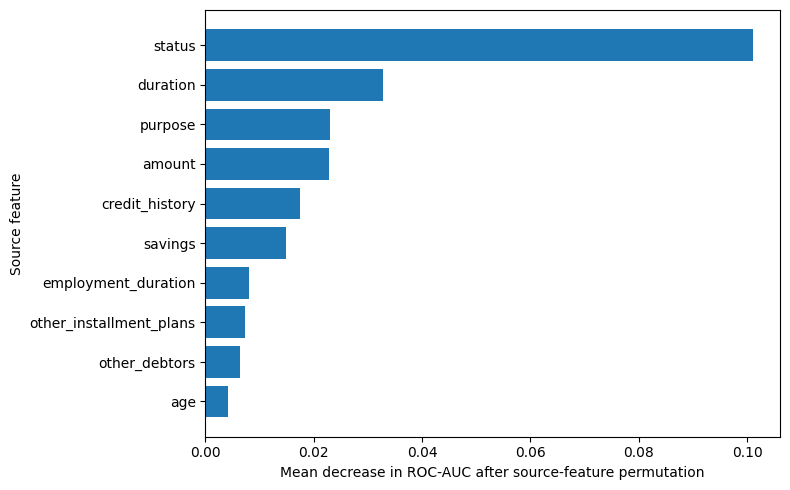

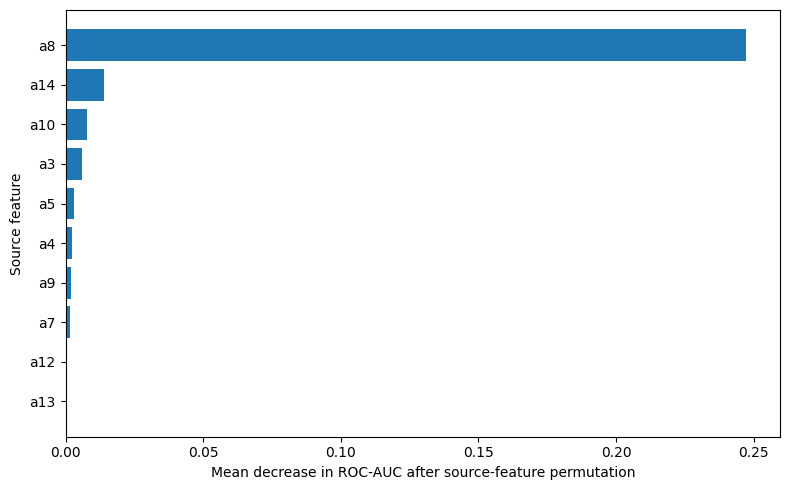

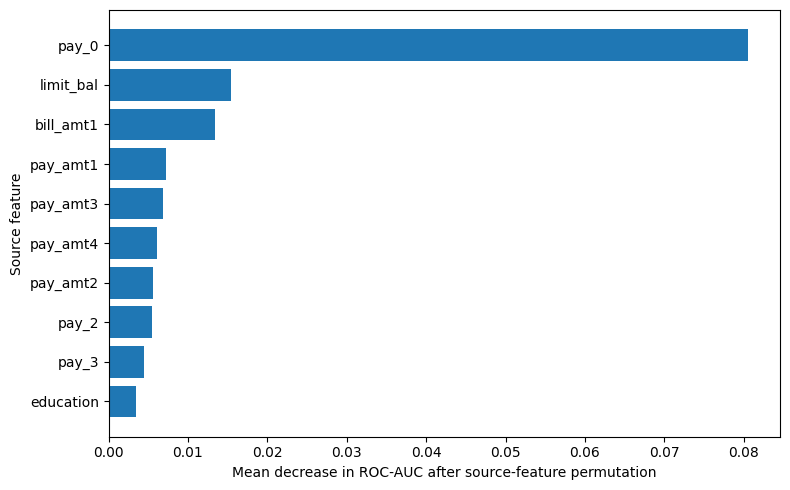

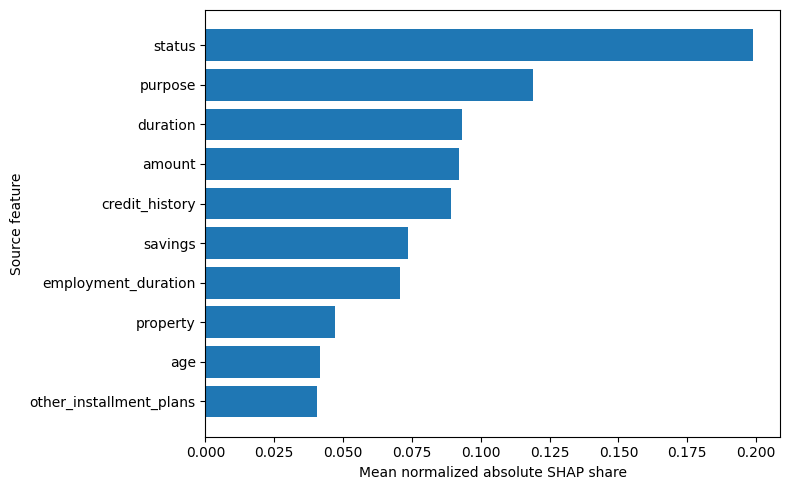

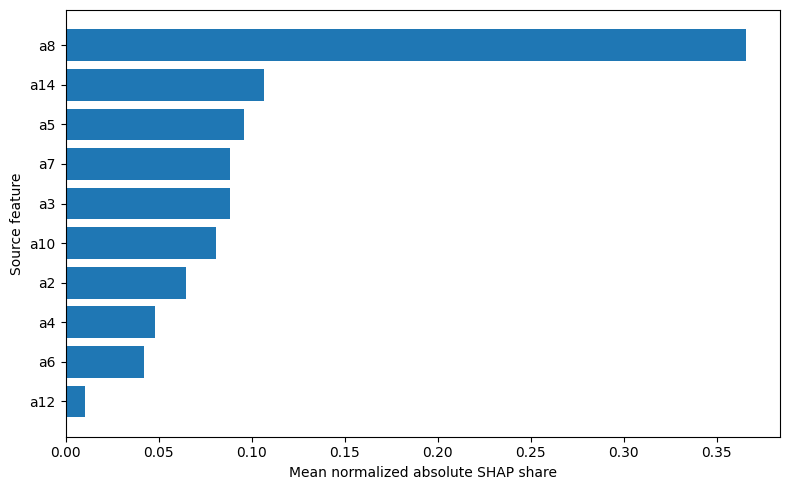

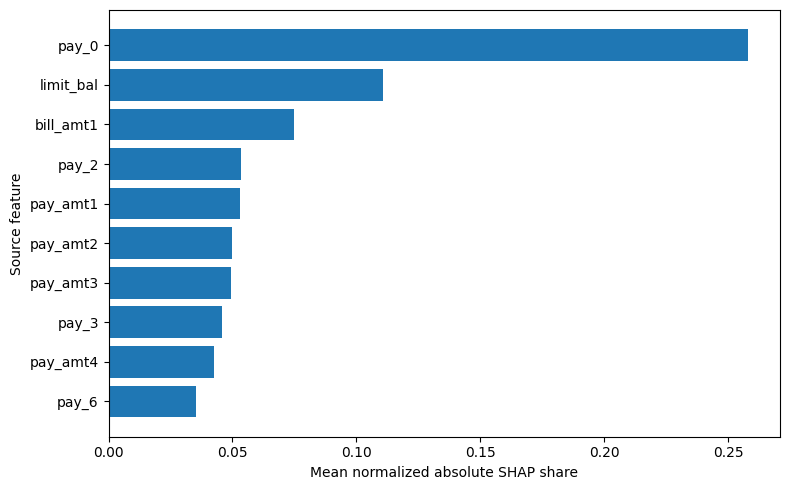

In [15]:

for dataset_name in DATASET_ORDER:
    temp = (
        permutation_summary[
            permutation_summary[
                "dataset"
            ]
            == dataset_name
        ]
        .sort_values(
            "ROC_AUC_Drop_Mean",
            ascending=False,
        )
        .head(
            10
        )
        .sort_values(
            "ROC_AUC_Drop_Mean",
            ascending=True,
        )
    )

    plt.figure(
        figsize=(
            8,
            5,
        )
    )

    plt.barh(
        temp[
            "source_feature"
        ],
        temp[
            "ROC_AUC_Drop_Mean"
        ],
    )

    plt.xlabel(
        "Mean decrease in ROC-AUC after source-feature permutation"
    )

    plt.ylabel(
        "Source feature"
    )

    plt.tight_layout()

    safe_name = (
        dataset_name
        .lower()
        .replace(
            " ",
            "_",
        )
    )

    plt.savefig(
        FIG_DIR
        / (
            safe_name
            + "_hybrid_permutation_importance.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


for dataset_name in DATASET_ORDER:
    temp = (
        shap_summary[
            shap_summary[
                "dataset"
            ]
            == dataset_name
        ]
        .sort_values(
            "SHAP_Share_Mean",
            ascending=False,
        )
        .head(
            10
        )
        .sort_values(
            "SHAP_Share_Mean",
            ascending=True,
        )
    )

    plt.figure(
        figsize=(
            8,
            5,
        )
    )

    plt.barh(
        temp[
            "source_feature"
        ],
        temp[
            "SHAP_Share_Mean"
        ],
    )

    plt.xlabel(
        "Mean normalized absolute SHAP share"
    )

    plt.ylabel(
        "Source feature"
    )

    plt.tight_layout()

    safe_name = (
        dataset_name
        .lower()
        .replace(
            " ",
            "_",
        )
    )

    plt.savefig(
        FIG_DIR
        / (
            safe_name
            + "_xgb_source_shap.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


## 14. Final consistency checks and manifest

Interpretation rules for the manuscript:

- **Permutation importance is the primary explanation of the complete hybrid.**
- **SHAP results explain only the XGBoost component.**
- Importance is associative/predictive, not causal.
- A variable with low importance is not necessarily unimportant in a policy, ethical, or causal sense.
- Correlated predictors can share or mask permutation importance.
- Test-fold permutation importance is used only after all model-development decisions have been frozen.


In [16]:

assert len(
    verification
) == (
    3
    * 25
)

assert verification[
    "max_abs_probability_difference"
].max() < 1e-10

expected_selection_rows = sum(
    25
    * (
        len(
            roles[
                dataset_name
            ][
                "categorical"
            ]
        )
        + len(
            roles[
                dataset_name
            ][
                "ordinal"
            ]
        )
        + len(
            roles[
                dataset_name
            ][
                "numerical"
            ]
        )
    )
    for dataset_name
    in DATASET_ORDER
)

assert len(
    selection_detail
) == expected_selection_rows

assert len(
    permutation_summary
) == sum(
    len(
        roles[
            dataset_name
        ][
            "categorical"
        ]
    )
    + len(
        roles[
            dataset_name
        ][
            "ordinal"
        ]
    )
    + len(
        roles[
            dataset_name
        ][
            "numerical"
        ]
    )
    for dataset_name
    in DATASET_ORDER
)

assert len(
    shap_summary
) == len(
    permutation_summary
)

configuration = {
    "stage": (
        "Objective 3 Step 14 - final explainability analysis"
    ),
    "framework_status": "frozen",
    "primary_explanation": (
        "Source-feature permutation importance for complete calibrated "
        "soft-voting hybrid at the frozen cost-aware threshold"
    ),
    "permutation_repeats": (
        PERMUTATION_REPEATS
    ),
    "permutation_metrics": [
        "ROC-AUC decrease",
        "PR-AUC decrease",
        "MCC decrease",
        "Balanced-accuracy decrease",
        "Brier increase",
        "Log-loss increase",
    ],
    "component_explanation": (
        "Native XGBoost SHAP contributions aggregated to source features"
    ),
    "shap_scope": (
        "XGBoost component only; not the entire hybrid"
    ),
    "shap_max_records_per_outer_fold": (
        SHAP_MAX_RECORDS_PER_OUTER_FOLD
    ),
    "causal_interpretation": False,
}

with open(
    OUT_DIR
    / "step14_experiment_configuration.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        configuration,
        file,
        indent=4,
    )

manifest = sorted(
    [
        path.relative_to(
            OUT_DIR
        ).as_posix()
        for path
        in OUT_DIR.rglob(
            "*"
        )
        if path.is_file()
    ]
)

pd.DataFrame(
    {
        "generated_file": manifest
    }
).to_csv(
    OUT_DIR
    / "step14_output_manifest.csv",
    index=False,
)

print("=" * 80)
print("STEP 14 COMPLETED SUCCESSFULLY")
print("=" * 80)
print("Output folder:", OUT_DIR)
print("\nMost important files:")
print(" - full_hybrid_source_permutation_importance_summary.csv")
print(" - xgb_source_shap_summary.csv")
print(" - combined_source_feature_explainability.csv")
print(" - permutation_shap_rank_agreement.csv")
print(" - manuscript_top_source_features.csv")
print(" - figures/")


STEP 14 COMPLETED SUCCESSFULLY
Output folder: D:\PHD\Research Paper writing\3rd Obj. paper\results\final_explainability

Most important files:
 - full_hybrid_source_permutation_importance_summary.csv
 - xgb_source_shap_summary.csv
 - combined_source_feature_explainability.csv
 - permutation_shap_rank_agreement.csv
 - manuscript_top_source_features.csv
 - figures/
